In [2]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import mnist

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [3]:
# ==========================================================
# Load MNIST Dataset
# ==========================================================

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Data Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print()

print("Testing Data Shape :", X_test.shape)
print("Testing Labels Shape :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training Data Shape : (60000, 28, 28)
Training Labels Shape : (60000,)

Testing Data Shape : (10000, 28, 28)
Testing Labels Shape : (10000,)


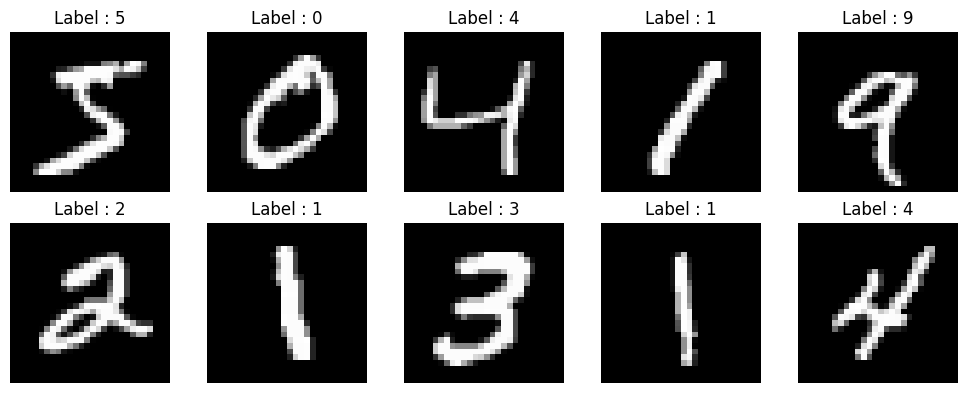

In [4]:
# ==========================================================
# Display Sample Images
# ==========================================================

plt.figure(figsize=(10,4))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(f"Label : {y_train[i]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [5]:
# ==========================================================
# Normalize the Dataset
# ==========================================================

X_train = X_train / 255.0

X_test = X_test / 255.0

print("Maximum Pixel Value :", X_train.max())
print("Minimum Pixel Value :", X_train.min())

Maximum Pixel Value : 1.0
Minimum Pixel Value : 0.0


In [6]:
# ==========================================================
# Dataset Shape after Normalization
# ==========================================================

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (60000, 28, 28)
Testing Data  : (10000, 28, 28)


In [7]:
# ==========================================================
# Build Artificial Neural Network (ANN)
# ==========================================================

model = tf.keras.Sequential([

    tf.keras.layers.Flatten(input_shape=(28, 28)),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(10, activation="softmax")

])

model.summary()

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ==========================================================
# Compile the ANN Model
# ==========================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
# ==========================================================
# Train the ANN Model
# ==========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9216 - loss: 0.2700 - val_accuracy: 0.9555 - val_loss: 0.1453
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9655 - loss: 0.1130 - val_accuracy: 0.9695 - val_loss: 0.1009
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9755 - loss: 0.0789 - val_accuracy: 0.9699 - val_loss: 0.0986
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9814 - loss: 0.0598 - val_accuracy: 0.9737 - val_loss: 0.0847
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9862 - loss: 0.0449 - val_accuracy: 0.9675 - val_loss: 0.1169
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9881 - loss: 0.0365 - val_accuracy: 0.9729 - val_loss: 0.1011
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9902 - loss: 0.0298 - val_accuracy: 0.9743 - val_loss: 0.0979
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9910 - loss: 0.0265 

In [11]:
# ==========================================================
# Model Evaluation
# ==========================================================

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", round(test_loss,4))
print("Test Accuracy :", round(test_accuracy*100,2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9757 - loss: 0.1093
Test Loss : 0.1093
Test Accuracy : 97.57 %


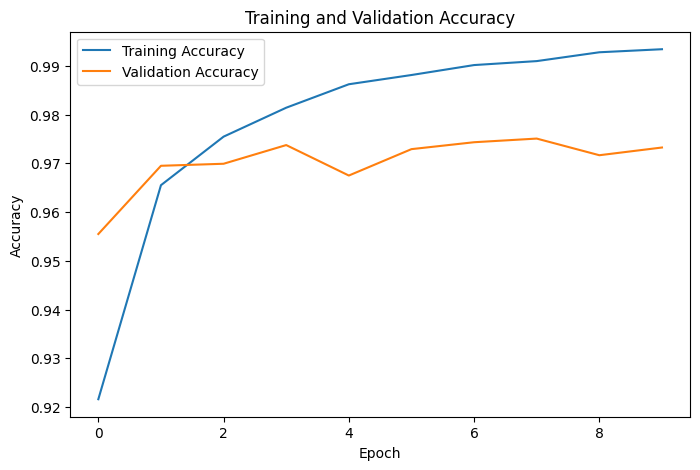

In [12]:
# ==========================================================
# Training and Validation Accuracy
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

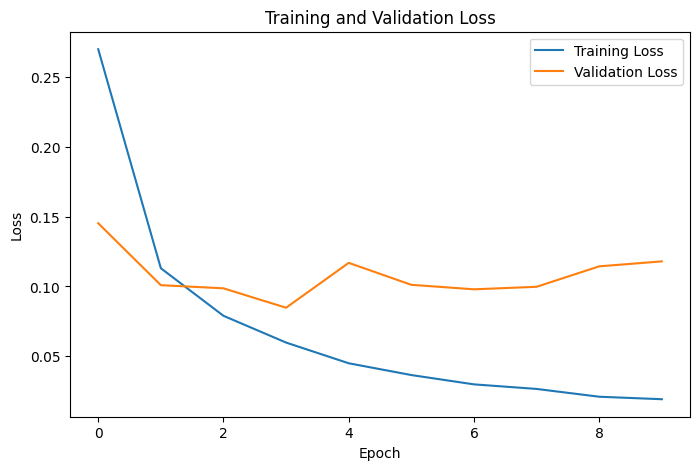

In [13]:
# ==========================================================
# Training and Validation Loss
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [14]:
# ==========================================================
# Predict the Class of 10 Test Images
# ==========================================================

predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


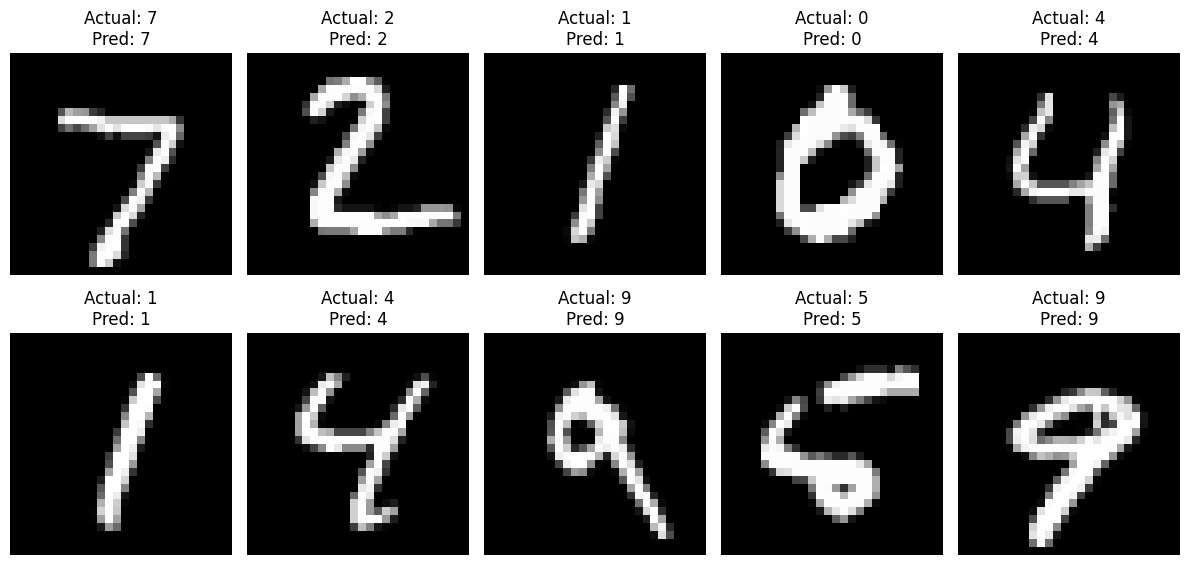

In [15]:
# ==========================================================
# Display Predictions
# ==========================================================

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i], cmap="gray")

    plt.title(f"Actual: {y_test[i]}\nPred: {predicted_labels[i]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [16]:
# ==========================================================
# Save ANN Model
# ==========================================================

import os
import joblib

os.makedirs("model", exist_ok=True)

model.save("model/digit_classifier_ann.keras")

print("ANN model saved successfully!")

ANN model saved successfully!


In [17]:
# ==========================================================
# Prediction Results
# ==========================================================

for i in range(10):
    print(
        f"Image {i+1}: Actual = {y_test[i]} | Predicted = {predicted_labels[i]}"
    )

Image 1: Actual = 7 | Predicted = 7
Image 2: Actual = 2 | Predicted = 2
Image 3: Actual = 1 | Predicted = 1
Image 4: Actual = 0 | Predicted = 0
Image 5: Actual = 4 | Predicted = 4
Image 6: Actual = 1 | Predicted = 1
Image 7: Actual = 4 | Predicted = 4
Image 8: Actual = 9 | Predicted = 9
Image 9: Actual = 5 | Predicted = 5
Image 10: Actual = 9 | Predicted = 9
